<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [1]:
# 데이터 가져오기
import pandas as pd
data = pd.read_csv('netflix_train.csv')
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


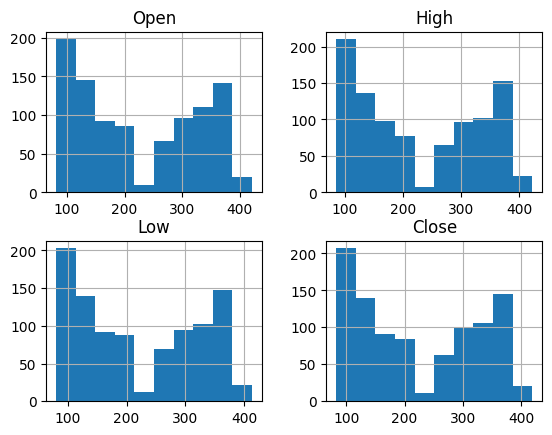

In [4]:
# 데이터 분포를 히스토그램으로 살펴보기
data_used = data[['Open', 'High', 'Low', 'Close']]
import matplotlib.pyplot as plt

# 개장가, 최고가, 최저가 추가
# 종가 추가
hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [5]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class Netflix(Dataset):
    def __init__(self):
        # 1. 데이터 읽기
        self.csv = pd.read_csv('netflix_train.csv')

        # 입력 데이터 추출 (개장가, 최고가, 최저가, 종가, 거래량)
        # 문자열인 'Date'를 제외한 수치 데이터만 사용합니다.
        self.data = self.csv.iloc[:, 1:].values.astype(np.float32)

        # 2. 데이터 정규화 (Min-Max Scaling)
        # 0과 1 사이로 값을 맞추어 학습 효율을 높입니다.
        self.min_val = np.min(self.data, axis=0)
        self.max_val = np.max(self.data, axis=0)
        self.data = (self.data - self.min_val) / (self.max_val - self.min_val)

        # 종가(Close) 데이터는 타겟(Label)이 되므로 별도로 관리합니다.
        # 데이터프레임 구조상 'Close'가 마지막(5번째) 컬럼이라고 가정합니다.
        self.label = self.data[:, -1]

    def __len__(self):
        # 30일치 데이터를 보고 다음날을 예측하므로 전체에서 30을 뺍니다.
        return len(self.data) - 30

    def __getitem__(self, i):
        # 입력 데이터: i부터 i+30 전까지 (30일치 일련의 데이터)
        data = self.data[i:i+30]

        # 정답 데이터: i+30번째 날의 종가
        label = self.label[i+30]

        return torch.tensor(data), torch.tensor(label)

# 데이터셋 객체 생성 및 확인
netflix_dataset = Netflix()
print(f"총 학습 가능 배치 개수: {len(netflix_dataset)}")

# 첫 번째 데이터 샘플 형태 확인
sample_data, sample_label = netflix_dataset[0]
print(f"입력 데이터 형상 (30일, 피처수): {sample_data.shape}")
print(f"정답 데이터: {sample_label}")

총 학습 가능 배치 개수: 937
입력 데이터 형상 (30일, 피처수): torch.Size([30, 5])
정답 데이터: 0.032738097012043


## 3. RNN 모델 정의

In [6]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(RNN, self).__init__()

        # 1. RNN 층의 정의 (입력: 5개 피처, 출력: 은닉 상태 크기)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

        # 2. 주가를 예측하는 MLP층 정의 (은닉 상태를 받아 1개의 값 예측)
        self.fc = nn.Linear(hidden_size, 1)

        # 3. 활성화 함수 정의
        self.relu = nn.ReLU()

    def forward(self, x, h0):
        # 4. RNN 층의 출력 (out: [batch, seq_len, hidden_size])
        out, _ = self.rnn(x, h0)

        # 5. MLP층의 입력으로 사용되게 모양 변경
        # (30일치 시퀀스 중 마지막 날의 은닉 상태만 선택)
        out = out[:, -1, :]

        # 6. MLP층을 이용해 종가 예측
        out = self.fc(out)

        # 7. 예측한 종가를 리턴 (batch, 1)
        return out

## 4. 모델 학습하기

In [7]:
import tqdm
from torch.optim import Adam
from torch.utils.data.dataloader import DataLoader

# GPU 사용 가능 여부 확인
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
# 피처 5개(Open, High, Low, Close, Volume), 은닉층 64개, 2층 RNN
model = RNN(input_size=5, hidden_size=64, num_layers=2).to(device)

# 데이터셋의 정의
# 앞서 만든 Netflix 클래스를 인스턴스화합니다.
dataset = Netflix()

In [8]:
# 데이터로더 정의
# 배치 크기를 32로 설정하여 데이터를 묶어서 공급합니다.
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [9]:
# 최적화 정의
# 학습률은 0.0001로 설정
learning_rate = 0.0001

# 사용할 최적화 설정 (Adam Optimizer)
optimizer = Adam(model.parameters(), lr=learning_rate)

# 손실 함수 정의 (주가 예측은 회귀 문제이므로 MSE 사용)
criterion = nn.MSELoss()

In [10]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
    iterator = tqdm.tqdm(loader)
    for data, label in iterator:
        # 기울기 초기화
        optimizer.zero_grad()

        # 초기 은닉 상태 설정 (층 수, 배치 크기, 은닉 상태 크기)
        # 이전 섹션에서 설정한 파라미터(num_layers=2, hidden_size=64) 기준입니다.
        h0 = torch.zeros(2, data.size(0), 64).to(device)

        # 모델의 예측값
        # 입력 데이터와 초기 은닉 상태를 GPU/CPU 장치로 보냅니다.
        pred = model(data.to(device), h0)

        # 손실의 계산 (예측값과 실제 정답 레이블 비교)
        loss = criterion(pred, label.to(device))

        # 오차 역전파
        loss.backward()

        # 최적화 진행 (가중치 업데이트)
        optimizer.step()

        # 진행 상황 표시
        iterator.set_description(f"epoch {epoch} loss:{loss.item():.6f}")

# 모델 저장
# 학습된 파라미터를 'netflix_rnn.pth' 파일로 저장합니다.
torch.save(model.state_dict(), "netflix_rnn.pth")

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch 0 loss:0.163925:  97%|█████████▋| 29/30 [00:00<00:00, 48.70it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([9])) that is different to the input size (torch.Size([9, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch 199 loss:0.062081: 100%|██████████| 30/30 [00:00<00:00, 64.03it/s]


## 5. 모델 성능 평가하기

In [11]:
import matplotlib.pyplot as plt

# 예측값을 위한 데이터로더 (평가용이므로 shuffle=False 권장)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# 예측값들을 저장하는 리스트
preds = []
total_loss = 0

with torch.no_grad(): # 평가 시에는 기울기 계산을 하지 않음
    # 모델의 가중치 불러오기 (이전 단계에서 저장한 파일명)
    model.load_state_dict(torch.load("netflix_rnn.pth", map_location=device))
    model.eval() # 평가 모드로 전환

    for data, label in loader:
        # 초기 은닉 상태 정의
        h0 = torch.zeros(2, data.size(0), 64).to(device)

        # 모델의 예측값 출력
        pred = model(data.to(device), h0)

        # 예측값을 리스트에 추가 (시각화를 위해 cpu로 옮겨 저장)
        preds.extend(pred.detach().cpu().numpy())

        # 손실 계산
        loss = criterion(pred, label.to(device))
        total_loss += loss

    # 손실의 평균치 계산
    avg_loss = total_loss / len(loader)

# 최종 평균 손실 출력
print(f"Average Loss: {avg_loss.item()}")

Average Loss: 0.08852502703666687


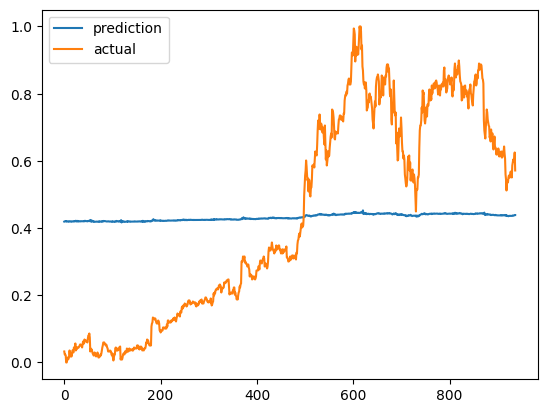

In [12]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.label[30:], label="actual")
plt.legend()
plt.show()